1. Suponha que você está trabalhando em um projeto para um banco e sua equipe precisa implementar um novo serviço que envolve o cadastramento de novos clientes, além de consulta e exclusão de cadastros existentes. A partir da análise de outros serviços similares em produção, há uma expectativa de que o novo serviço receba a cada segundo, em média, 11 requisições de cadastramento de novos clientes, 11 requisições de exclusão de cadastros e 34 requisições de consulta pelo CPF do cliente. Considerando que o banco possui atualmente uma base com milhões de clientes e o processamento dessas requisições pode ter impacto direto no faturamento da instituição, a eficiência é um aspecto muito importante para o serviço a ser desenvolvido.

O líder da sua equipe delegou para você a escolha da estrutura de dados mais adequada para armazenar os cadastros dentre 2 alternativas: um array simples (não ordenado) ou um array ordenado pelo CPF dos clientes. Você deve: 

a. Indicar qual das alternativas propostas considera a mais adequada para o cenário descrito acima;

b. Explicar como essa escolha afetaria a eficiência do serviço desenvolvido;

c. Apresentar uma análise comparando o desempenho esperado das estruturas de dados consideradas no processamento das requisições.

a. A melhor escolha para armazenar os cadastros de clientes nesse cenário é um **array ordenado pelo CPF**.

b. O principal motivo para essa escolha é a necessidade de eficiência nas consultas, que representam a maior parte das requisições (34 por segundo). Em um array ordenado, é possível realizar buscas de forma mais eficiente utilizando busca binária, que tem complexidade O(log N). Já um array não ordenado exigiria busca linear (O(N)), tornando o tempo de resposta significativamente maior à medida que a base cresce. Embora o cadastramento e a exclusão sejam mais rápidos em um array não ordenado, o impacto negativo na eficiência das consultas torna essa opção inviável para um sistema de alto desempenho.

c. <br>
**Array Não Ordenado**:<br>
**Cadastro**: O(1) (inserção no final),<br>
**Exclusão**: O(N) (busca linear e remoção),<br>
**Consulta**: O(N) (busca linear)<br>

**Array Ordenado**:<br>
**Cadastro**: O(N) (devido ao deslocamento necessário para manter a ordenação),<br>
**Exclusão**: O(N) (busca binária + deslocamento),<br>
**Consulta**: O(log N) (busca binária)<br>

2. No TP3, abordamos a implementação de uma funcionalidade de ordenação no contexto de um componente para seleção de cores. Considerando que você implementou a função solicitada no TP3, agora as listas de cores estão ordenadas, conforme o exemplo apresentado abaixo, de acordo com os seguintes critérios: (1) primariamente em ordem crescente do valor de R; (2) caso haja empate em relação ao R, é considerada a ordem crescente do valor de G; (3) caso haja empate em relação a R e G, é considerada a ordem crescente do valor de B.

Agora você deve escrever 2 funções para buscar uma cor em uma lista ordenada conforme a descrição acima:

a. Na 1ª função, a busca deve ser realizada pelo nome da cor. Como a lista não está ordenada pelo nome, será necessário implementar um algoritmo de busca linear neste caso;

b. Na 2ª função, a busca deve ser realizada pelo código RGB da cor. Como a lista está ordenada por esta informação, você deve implementar um algoritmo de busca binária para otimizar esta função.

In [59]:
cores = [
    {"nome": "preto", "r": 0, "g": 0, "b": 0},
    {"nome": "azul", "r": 0, "g": 0, "b": 255},
    {"nome": "verde", "r": 0, "g": 255, "b": 0},
    {"nome": "roxo", "r": 153, "g": 0, "b": 255},
    {"nome": "vermelho", "r": 255, "g": 0, "b": 0},
    {"nome": "laranja", "r": 255, "g": 153, "b": 0},
    {"nome": "amarelo", "r": 255, "g": 255, "b": 0},
    {"nome": "branco", "r": 255, "g": 255, "b": 255}
]

def busca_linear_nome(cores, nome):
    for cor in cores:
        if cor["nome"].lower() == nome.lower():
            return cor
    return "Cor não encontrada"  # Retorna None se a cor não for encontrada

def busca_binaria_rgb(cores, r, g, b):
    esquerda, direita = 0, len(cores) - 1

    while esquerda <= direita:
        meio = (esquerda + direita) // 2
        cor_meio = cores[meio]

        if (cor_meio["r"], cor_meio["g"], cor_meio["b"]) == (r, g, b):
            return cor_meio
        elif (cor_meio["r"], cor_meio["g"], cor_meio["b"]) < (r, g, b):
            esquerda = meio + 1
        else:
            direita = meio - 1

    return "Cor não encontrada"

print(busca_linear_nome(cores, "verde"))
print(busca_binaria_rgb(cores, 255, 255, 255))  # branco
print(busca_binaria_rgb(cores, 128, 128, 128))  # cor não existente

{'nome': 'verde', 'r': 0, 'g': 255, 'b': 0}
{'nome': 'branco', 'r': 255, 'g': 255, 'b': 255}
Cor não encontrada


3. No TP2, abordamos a implementação de funcionalidades de ordenação no contexto de uma aplicação que processa registros de candidatos em um processo seletivo, representados conforme o exemplo apresentado abaixo.

[{'ni': 1, 'nome': 'José', 'idade': 28, 'pontos': 97},
 {'ni': 2, 'nome': 'Márcia', 'idade': 36, 'pontos': 95},
 {'ni': 3, 'nome': 'André', 'idade': 22, 'pontos': 90},
 {'ni': 4, 'nome': 'Bruna', 'idade': 38, 'pontos': 95}]

Retomando o contexto daquela aplicação, vamos agora aprimorar suas funções de ordenação, tornando-as mais flexíveis. Em vez de usar um critério de ordenação fixo, o critério de ordenação será definido por um parâmetro. O novo parâmetro deverá receber uma função “chave”. A função “chave” deve receber um objeto do tipo contido no array a ser ordenado (na nossa aplicação, um registro de candidato) e retornar uma chave (simples ou composta) que será usada para comparar o objeto em questão com outro do mesmo tipo usando operadores relacionais (=, <, >, <=, >=) a fim de se determinar a relação de ordem entre esses objetos. Esta abordagem tem a vantagem de tornar as funções de ordenação aplicáveis a qualquer tipo de objeto, uma vez que os critérios de comparação são especificados pelo parâmetro correspondente à função “chave” definida externamente.

Você deverá implementar pelo menos 2 funções “chave” correspondentes a critérios de ordenação diferentes (os mesmos usados no TP2). De acordo com o 1º critério, a lista deverá ser ordenada em ordem alfabética de nome (case insensitive). Já o 2º critério é composto: (1) os registros devem ser ordenados primariamente em ordem decrescente de pontuação; (2) caso haja empate na pontuação, deve ser considerada a ordem decrescente de idade.

Você deve escrever 4 funções para ordenar uma lista conforme a descrição acima:

a. Uma implementação do algoritmo bubble sort;

b. Uma implementação do algoritmo selection sort;

c. Uma implementação do algoritmo insertion sort;

b. Uma implementação do algoritmo quicksort.

In [60]:
candidatos = [
    {"ni": 1, "nome": "José", "idade": 28, "pontos": 97},
    {"ni": 2, "nome": "Márcia", "idade": 36, "pontos": 95},
    {"ni": 3, "nome": "André", "idade": 22, "pontos": 90},
    {"ni": 4, "nome": "Bruna", "idade": 38, "pontos": 95}
]

# Funções "chave" para definir o critério de ordenação
def chave_por_nome(candidato):
    return candidato["nome"].lower()

def chave_por_pontuacao_idade(candidato):
    return (-candidato["pontos"], -candidato["idade"])

# Bubble Sort
def bubble_sort(lista, key):
    lista = lista[:]
    n = len(lista)
    for i in range(n):
        for j in range(n - 1 - i):
            if key(lista[j]) > key(lista[j + 1]):
                lista[j], lista[j + 1] = lista[j + 1], lista[j]
    return lista

# Selection Sort
def selection_sort(lista, key):
    lista = lista[:]
    n = len(lista)
    for i in range(n - 1):
        min_idx = i
        for j in range(i + 1, n):
            if key(lista[j]) < key(lista[min_idx]):
                min_idx = j
        lista[i], lista[min_idx] = lista[min_idx], lista[i]
    return lista

# Insertion Sort
def insertion_sort(lista, key):
    lista = lista[:]
    n = len(lista)
    for i in range(1, n):
        chave = lista[i]
        j = i - 1
        while j >= 0 and key(lista[j]) > key(chave):
            lista[j + 1] = lista[j]
            j -= 1
        lista[j + 1] = chave
    return lista

# Quicksort
def quicksort(lista, key):
    if len(lista) <= 1:
        return lista
    pivo = lista[len(lista) // 2] # meio da lista
    menores = [x for x in lista if key(x) < key(pivo)]
    iguais = [x for x in lista if key(x) == key(pivo)]
    maiores = [x for x in lista if key(x) > key(pivo)]
    return quicksort(menores, key) + iguais + quicksort(maiores, key)

# Testes
print("\nBubble Sort (Nome):")
candidatos_bubble = bubble_sort(candidatos, chave_por_nome)
print(candidatos_bubble)

print("\nSelection Sort (Nome):")
candidatos_selection = selection_sort(candidatos, chave_por_nome)
print(candidatos_selection)

print("\nInsertion Sort (Pontuação e Idade):")
candidatos_insertion = insertion_sort(candidatos, chave_por_pontuacao_idade)
print(candidatos_insertion)

print("\nQuicksort (Pontuação e Idade):")
candidatos_quick = quicksort(candidatos, chave_por_pontuacao_idade)
print(candidatos_quick)



Bubble Sort (Nome):
[{'ni': 3, 'nome': 'André', 'idade': 22, 'pontos': 90}, {'ni': 4, 'nome': 'Bruna', 'idade': 38, 'pontos': 95}, {'ni': 1, 'nome': 'José', 'idade': 28, 'pontos': 97}, {'ni': 2, 'nome': 'Márcia', 'idade': 36, 'pontos': 95}]

Selection Sort (Nome):
[{'ni': 3, 'nome': 'André', 'idade': 22, 'pontos': 90}, {'ni': 4, 'nome': 'Bruna', 'idade': 38, 'pontos': 95}, {'ni': 1, 'nome': 'José', 'idade': 28, 'pontos': 97}, {'ni': 2, 'nome': 'Márcia', 'idade': 36, 'pontos': 95}]

Insertion Sort (Pontuação e Idade):
[{'ni': 1, 'nome': 'José', 'idade': 28, 'pontos': 97}, {'ni': 4, 'nome': 'Bruna', 'idade': 38, 'pontos': 95}, {'ni': 2, 'nome': 'Márcia', 'idade': 36, 'pontos': 95}, {'ni': 3, 'nome': 'André', 'idade': 22, 'pontos': 90}]

Quicksort (Pontuação e Idade):
[{'ni': 1, 'nome': 'José', 'idade': 28, 'pontos': 97}, {'ni': 4, 'nome': 'Bruna', 'idade': 38, 'pontos': 95}, {'ni': 2, 'nome': 'Márcia', 'idade': 36, 'pontos': 95}, {'ni': 3, 'nome': 'André', 'idade': 22, 'pontos': 90}]


4. Ainda no contexto da aplicação discutida na questão anterior, vamos agora abordar uma funcionalidade para identificação dos melhores candidatos. Desenvolva uma função que implemente o algoritmo quickselect para encontrar (em uma lista não ordenada com o formato do exemplo da questão anterior) e retornar os 25% melhores candidatos considerando os seguintes critérios: (1) serão selecionados primariamente os candidatos com pontuação mais alta; (2) caso haja empate na pontuação, serão selecionados os candidatos com maior idade; (3) caso haja empate tanto na pontuação quanto na idade, serão selecionados os candidatos que se inscreveram antes no processo seletivo, ou seja, aqueles com menor nº de inscrição.

A função deve receber a lista contendo todos os candidatos e retornar outra lista contendo apenas os 25% melhores candidatos de acordo com os critérios acima (a lista retornada não precisa estar ordenada).

In [61]:
candidatos = [
    {"ni": 1, "nome": "José", "idade": 28, "pontos": 97},
    {"ni": 2, "nome": "Márcia", "idade": 36, "pontos": 95},
    {"ni": 3, "nome": "André", "idade": 22, "pontos": 90},
    {"ni": 4, "nome": "Bruna", "idade": 38, "pontos": 95}
]

# Funções "chave" para definir o critério de ordenação
def chave_por_nome(candidato):
    return candidato["nome"].lower()

def chave_por_pontuacao_idade(candidato):
    return (-candidato["pontos"], -candidato["idade"], candidato["ni"])

# Bubble Sort
def bubble_sort(lista, key):
    n = len(lista)
    for i in range(n):
        for j in range(n - 1 - i):
            if key(lista[j]) > key(lista[j + 1]):
                lista[j], lista[j + 1] = lista[j + 1], lista[j]

# Selection Sort
def selection_sort(lista, key):
    n = len(lista)
    for i in range(n - 1):
        min_idx = i
        for j in range(i + 1, n):
            if key(lista[j]) < key(lista[min_idx]):
                min_idx = j
        lista[i], lista[min_idx] = lista[min_idx], lista[i]

# Insertion Sort
def insertion_sort(lista, key):
    n = len(lista)
    for i in range(1, n):
        chave = lista[i]
        j = i - 1
        while j >= 0 and key(lista[j]) > key(chave):
            lista[j + 1] = lista[j]
            j -= 1
        lista[j + 1] = chave

# Quicksort
def quicksort(lista, key):
    if len(lista) <= 1:
        return lista
    pivo = lista[len(lista) // 2]
    menores = [x for x in lista if key(x) < key(pivo)]
    iguais = [x for x in lista if key(x) == key(pivo)]
    maiores = [x for x in lista if key(x) > key(pivo)]
    return quicksort(menores, key) + iguais + quicksort(maiores, key)

# Quickselect para encontrar os 25% melhores candidatos
def quickselect(lista, k, key):
    if len(lista) <= k:
        return lista
    pivo = lista[len(lista) // 2]
    maiores = [x for x in lista if key(x) > key(pivo)]
    iguais = [x for x in lista if key(x) == key(pivo)]
    menores = [x for x in lista if key(x) < key(pivo)]
    
    if len(maiores) >= k:
        return quickselect(maiores, k, key)
    elif len(maiores) + len(iguais) >= k:
        return maiores + iguais[:k - len(maiores)]
    else:
        return maiores + iguais + quickselect(menores, k - len(maiores) - len(iguais), key)

def selecionar_melhores_candidatos(lista):
    k = max(1, len(lista) * 25 // 100)  # 25% dos melhores candidatos
    return quickselect(lista, k, chave_por_pontuacao_idade)

# Teste das ordenações
print("\nMelhores Candidatos (Quickselect - 25% melhores):")
melhores_candidatos = selecionar_melhores_candidatos(candidatos)
print(melhores_candidatos)



Melhores Candidatos (Quickselect - 25% melhores):
[{'ni': 3, 'nome': 'André', 'idade': 22, 'pontos': 90}]


5. Use a notação Big O para indicar a complexidade de cada uma das 4 funções de ordenação implementadas na Questão 3. Com base nesta análise, qual delas você escolheria para usar em uma aplicação real? Justifique sua resposta, explicando:

Como a notação Big O é usada para mensurar a eficiência dessas funções?

Como essa escolha afetaria o desempenho da aplicação?

Entre as opções, **Quicksort** é a melhor escolha para uma aplicação real, pois, embora possa atingir O(N2) no pior caso, sua implementação prática costuma ser muito eficiente. Os algoritmos quadráticos, como Bubble Sort, Selection Sort e Insertion Sort, são inadequados para grandes volumes de dados, pois a quantidade de comparações cresce rapidamente, tornando a ordenação lenta.

A escolha do algoritmo afeta diretamente o desempenho da aplicação, pois um algoritmo ineficiente pode tornar a ordenação inviável para grandes listas. Enquanto os métodos quadráticos podem ser aceitáveis para pequenas listas, para grandes volumes de dados, um algoritmo mais otimizado, como uma variação eficiente do Quicksort **O(NlogN)** no pior caso, é essencial para garantir tempos de processamento razoáveis e boa experiência do usuário.

6. Use a notação Big O para descrever a complexidade da função abaixo, **justificando sua resposta**. A função recebe uma lista de currículos, escolhe um deles e o retorna.



In [62]:
def escolhe_curriculo(curriculos):
  eliminar = "topo"
  while len(curriculos) > 1:
    if eliminar == "topo":
      curriculos = curriculos[len(curriculos) // 2:]
      eliminar = "fundo"
    else:
      curriculos = curriculos[:len(curriculos) // 2]
      eliminar = "topo"
  return curriculos[0]

A complexidade da função `escolhe_curriculo` é **O(logN)**. Em cada iteração do `loop while`, a lista de currículos é reduzida pela metade, pois a operação `curriculos[len(curriculos) // 2:]` ou `curriculos[:len(curriculos) // 2]` elimina aproximadamente metade dos elementos restantes.

A cada rodada do loop, a função elimina metade dos currículos da lista. Primeiro, ela remove a metade de cima, depois a metade de baixo, e continua assim até sobrar apenas um currículo. Como a quantidade de currículos vai diminuindo rapidamente, o número de vezes que o loop precisa rodar é aproximadamente o número de vezes que podemos dividir o total inicial por 2 até chegar a 1. Esse número de divisões é dado pelo logaritmo do tamanho da lista, por isso a complexidade é  **O(logN)**. Sendo assim um método muito eficiente para listas grandes.

7. O código abaixo define uma função que conta o nº de ocorrências de cada item em uma lista e retorna um dicionário no qual cada entrada tem como chave o item e como valor o nº de ocorrências correspondente. Esta implementação da função tem complexidade O(N2). Otimize o código de modo que a função realize a mesma tarefa, mas com complexidade O(N).

In [63]:
def conta_ocorrencias(lista):
  ocorrencias = {}
  for i in range(len(lista)):
    if lista[i] not in ocorrencias:
      cont = 1
      for j in range(i + 1, len(lista)):
        if lista[i] == lista[j]:
          cont += 1
      ocorrencias[lista[i]] = cont
  return ocorrencias

lista = ["banana", "maçã", "banana", "laranja", "maçã", "banana", "uva"]

resultado = conta_ocorrencias(lista)
print(resultado)


{'banana': 3, 'maçã': 2, 'laranja': 1, 'uva': 1}


In [64]:
# Resposta:
def conta_ocorrencias(lista):
    ocorrencias = {}
    for item in lista:
        if item in ocorrencias:
            ocorrencias[item] += 1
        else:
            ocorrencias[item] = 1
    return ocorrencias
lista = ["banana", "maçã", "banana", "laranja", "maçã", "banana", "uva"]

resultado = conta_ocorrencias(lista)
print(resultado)

{'banana': 3, 'maçã': 2, 'laranja': 1, 'uva': 1}


8. Escreva uma função chamada “letra_faltante” que recebe uma string e retorna a 1ª letra do alfabeto que não ocorre nessa string. Por exemplo, na string “um cachorro fatigado salta rapidamente sobre uma caixa marrom”, a 1ª letra faltante é “j”. Então sua função deveria retornar “j” neste caso. Sua função deve ter **complexidade O(N)**.

In [65]:
def letra_faltante(s):
    letras_presentes = set(s.lower())  # cria um conjunto com os caracteres únicos
    alfabeto = "abcdefghijklmnopqrstuvwxyz"
    
    for letra in alfabeto:
        if letra not in letras_presentes:
            return letra  # Retorna a 1º letra que falta
    return "Todas as letras estão presentes" 

frase = "um cachorro fatigado salta rapidamente sobre uma caixa marrom"
print(letra_faltante(frase))  # Saída esperada: "j"
print(letra_faltante("abcdefghijklmnopqrstuvwxyz"))  


j
Todas as letras estão presentes


9. Escreva um programa que extraia as palavras individuais contidas em um arquivo de texto e conta as ocorrências de cada uma delas. Teste seu programa com um arquivo de texto pequeno.

Sua implementação deve ser eficiente tanto em relação ao tempo de processamento quanto ao consumo de memória. Mais precisamente, as seguintes restrições deverão ser respeitadas: (1) a complexidade do algoritmo implementado deve ser O(N) no pior caso, onde N é o tamanho do arquivo; e (2) ao ler o arquivo, o programa não pode manter mais que 1 linha na memória simultaneamente.

**Entrada**: Seu programa deverá receber (como argumento de linha de comando) o caminho de um arquivo de texto.

**Saída**: Seu programa deverá imprimir no console cada palavra individual encontrada no arquivo e seu nº de ocorrências.

**Exemplo**:

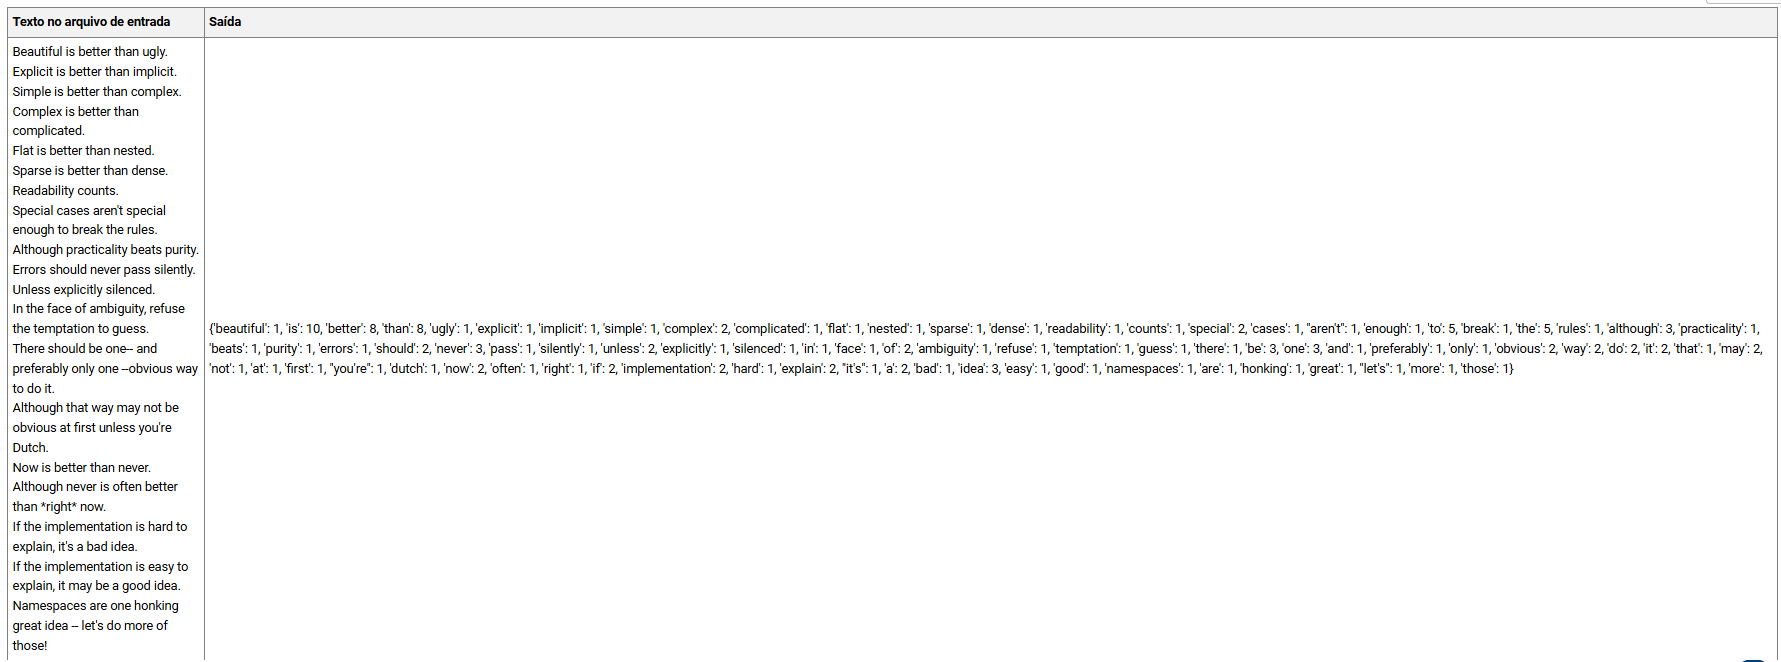

In [66]:
def conta_palavras(arquivo):
    contagem = {}  

    with open(arquivo, "r", encoding="utf-8") as f:
        for linha in f:
            linha = linha.lower().replace(".", "").replace(",", "").replace("!", "").replace("?", "")  # Remove pontuações
            palavras = linha.split()  # Separa palavras por espaços
            for palavra in palavras:
                if palavra in contagem:
                    contagem[palavra] += 1
                else:
                    contagem[palavra] = 1
    return contagem

arquivo_teste = "ex9.txt"
resultado = conta_palavras(arquivo_teste)
print(resultado)


FileNotFoundError: [Errno 2] No such file or directory: 'ex9.txt'

10. Nossa implementação da classe Pilha apresentada em aula usa um array como estrutura de armazenamento interna. Como sabemos, os arrays possuem algumas limitações cujas consequências incluem ineficiência ocasional em operações de inserção e potencial desperdício de memória. Uma alternativa interessante é usar uma lista encadeada como estrutura de armazenamento interna em vez de um array. Implemente uma classe Pilha desta forma, garantindo que todas as operações de inserção e remoção tenham complexidade O(1).

In [ ]:
class No:
    def __init__(self, valor):
        self.valor = valor
        self.proximo = None

class Pilha:
    def __init__(self):
        self.topo = None
        self.tamanho = 0
    
    def push(self, valor):
        novo_no = No(valor)
        novo_no.proximo = self.topo
        self.topo = novo_no
        self.tamanho += 1
    
    def pop(self):
        if self.esta_vazia():
            return ""
        valor = self.topo.valor
        self.topo = self.topo.proximo
        self.tamanho -= 1
        return valor
    
    def peek(self):
        if self.esta_vazia():
            return ""
        return self.topo.valor
    
    def esta_vazia(self):
        return self.topo is None
    
    def __len__(self):
        return self.tamanho

# Exemplo de uso
pilha = Pilha()
pilha.push(10)
pilha.push(20)
pilha.push(30)
print(len(pilha))
print(pilha.pop())  # 30
print(pilha.peek()) # 20
print(len(pilha))   # 2

3
30
20
2


11. Para organizar todo o fluxo de aviões que chegam e saem de um aeroporto, a torre de controle funciona o tempo inteiro com nível máximo de atenção. Para descartar qualquer possibilidade de erro humano, o chefe do controle de tráfego aéreo contratou você para desenvolver um sistema que organize automaticamente o fluxo de aviões na pista de pouso em uma **fila de pousos**.

O sistema deve seguir um protocolo segundo o qual os aviões devem ser colocados na fila de pousos de acordo com uma ordem de prioridade, definida pela direção de onde estão vindo: Oeste > Norte > Sul > Leste. Assim, na prática, o sistema deverá trabalhar com 4 filas auxiliares (uma para cada direção) que alimentarão a fila de pousos. O sistema deve alternar repetidamente entre as filas auxiliares (Oeste, Norte, Sul e Leste, nesta ordem), removendo um avião da fila (se houver algum) e incluindo tal avião na fila de pousos.

**Entrada**: Seu programa deverá receber (como argumento de linha de comando) o caminho de um arquivo contendo os dados dos aviões que solicitaram permissão para pousar (por ordem de solicitação). O conteúdo do arquivo é dividido em várias seções, cada uma com o seguinte formato: 1 linha indicando a direção, seguida por uma sequência de linhas, cada uma contendo o identificador de um avião vindo daquela direção indicada na 1ª linha da seção (os identificadores são formados por um “A” seguido de um nº).

**Saída**: Seu programa deverá imprimir uma linha contendo as aeronaves enfileiradas pela ordem do protocolo estabelecido pelo aeroporto.

**Exemplos**:

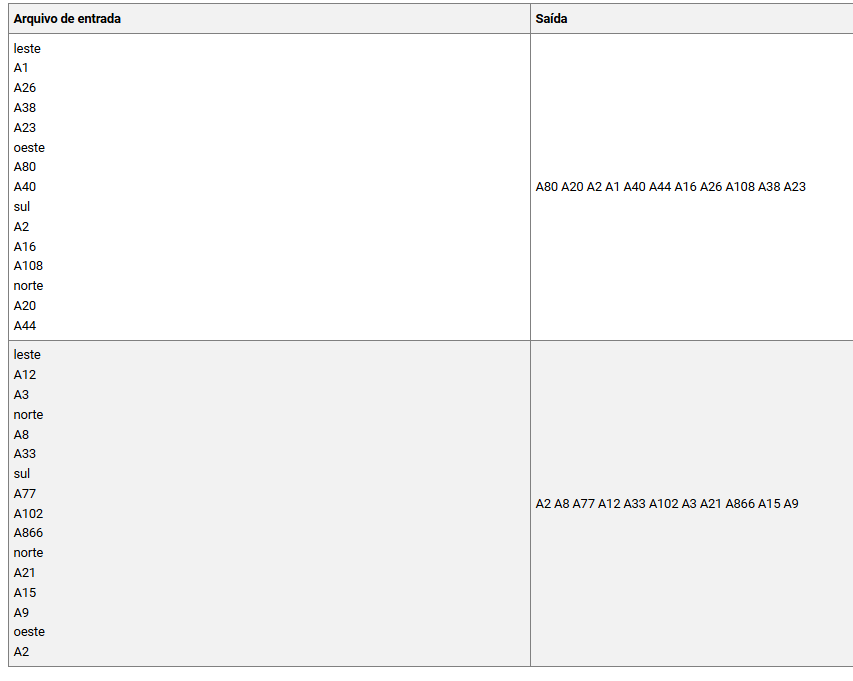

In [ ]:
def processar_pousos(caminho_arquivo):
    filas = {"oeste": [], "norte": [], "sul": [], "leste": []}
    ordem_prioridade = ["oeste", "norte", "sul", "leste"]
    
    with open(caminho_arquivo, "r") as arquivo:
        linhas = [linha.strip().lower() for linha in arquivo if linha.strip()]
    
    direcao_atual = None
    for linha in linhas:
        if linha in filas:
            direcao_atual = linha
        elif direcao_atual:
            filas[direcao_atual].append(linha.upper())
    
    fila_pousos = []
    while sum(len(filas[direcao]) for direcao in ordem_prioridade) > 0:
        for direcao in ordem_prioridade:
            if filas[direcao]:
                fila_pousos.append(filas[direcao].pop(0))
    
    print(" ".join(fila_pousos))

caminho_arquivo = "ex11.1.txt"
processar_pousos(caminho_arquivo)

caminho_arquivo = "ex11.2.txt"
processar_pousos(caminho_arquivo)

A80 A20 A2 A1 A40 A44 A16 A26 A108 A38 A23
A2 A8 A77 A12 A33 A102 A3 A21 A866 A15 A9


12. Escreva um programa recursivo que receba como argumento de linha de comando um caractere e imprima o caminho de todos os subdiretórios existentes no diretório corrente (em todos os níveis) cujos nomes comecem com o caractere de entrada.

In [ ]:
import os

def buscar_diretorios(caractere, caminho="."):
    print(f"Buscando diretórios que começam com '{caractere}'...")
    encontrou = False
    for raiz, dirs, _ in os.walk(caminho):
        for dir in sorted(dirs):
            if dir.startswith(caractere):
                print(os.path.join(raiz, dir))
                encontrou = True
    if not encontrou:
        print(f"Nenhum diretório encontrado que comece com '{caractere}'")
    
# Exemplo de uso
buscar_diretorios("A")
buscar_diretorios("t")
buscar_diretorios("e")
buscar_diretorios("i")

Buscando diretórios que começam com 'A'...
Nenhum diretório encontrado que comece com 'A'
Buscando diretórios que começam com 't'...
.\textos
Buscando diretórios que começam com 'e'...
Nenhum diretório encontrado que comece com 'e'
Buscando diretórios que começam com 'i'...
.\imagens


13. Suponha que você está trabalhando no projeto de um sistema embarcado para um dispositivo com uma capacidade de processamento muito limitada. O interpretador Python para este dispositivo só pode realizar 2 operações aritméticas: soma e subtração. Entretanto, o projeto requer operações de multiplicação de números inteiros.

Escreva uma função recursiva chamada “mult” que realiza a multiplicação de 2 valores inteiros X e Y, somando X em sequência Y vezes (ou vice-versa). Como os recursos do dispositivo são limitados, sua implementação deve ser tão eficiente quanto possível. Portanto, certifique-se de que o nº de chamadas recursivas seja o menor possível em cada caso.

In [ ]:
def mult(x, y):
    if y == 0:
        return 0
    if y < 0:
        return -mult(x, -y)
    return x + mult(x, y - 1)

print("Multiplicando 5 por 3:", mult(5, 3))  # 15
print("Multiplicando -4 por 6:", mult(-4, 6)) # -24
print("Multiplicando 7 por -2:", mult(7, -2)) # -14
print("Multiplicando -3 por -3:", mult(-3, -3)) # 9


15
-24
-14
9


14. Explique o funcionamento da função “mult” implementada em resposta à questão anterior, indicando como ela resolve o problema e como a recursão é usada neste caso.



- Se `y == 0`, o resultado da multiplicação é 0, pois qualquer número multiplicado por zero é zero.
- Tratamento de valores negativos: Se `y` for negativo, transformamos a multiplicação em um caso onde `y` seja positivo, ou seja, chamamos `mult(x, -y)` e, ao final, invertemos o sinal do resultado.

    - `mult(x, -y)` é calculado normalmente e, no final, o resultado é invertido (`-mult(x, -y)`).
- Se `y` for positivo, aplicamos a identidade matemática: 

`x * y = x + (x * (y − 1))`

Assim, reduzimos y a cada chamada recursiva até atingir 0.



15. A sequência de números “tribonacci” é parecida com a sequência de Fibonacci, mas em vez de começar com 2 números predeterminados, ela começa com 3 números pré determinados e cada termo a partir de então é a soma dos 3 termos anteriores:

T(0) = 0

T(1) = T(2) = 1

T(n) = T(n - 1) + T(n - 2) + T(n - 3) para n ≥ 3

A função abaixo retorna o n-ésimo termo da sequência “tribonacci”.

In [ ]:
def tribonacci(n):
  if n <= 0:
    return 0
  if n <= 2:
    return 1
  return tribonacci(n - 1) + tribonacci(n - 2) + tribonacci(n - 3)

Apresente uma análise do algoritmo implementado nesta função, indicando qual é sua complexidade na notação Big O e qual é seu principal problema (causa de ineficiência).



A complexidade temporal da função é **O(3^N)**, pois para cada chamada de `tribonacci(n)`, são feitas três chamadas recursivas, o que gera uma árvore de recursão exponencial. Isso resulta em um alto custo computacional devido à sua complexidade exponencial **O(3^N)**. O principal problema dessa implementação é a **recalculação de valores repetidos**, ou seja, a função calcula múltiplas vezes os mesmos termos da sequência, o que torna o algoritmo ineficiente, especialmente para valores grandes de N.

16. Reescreva a função “tribonacci” da questão anterior usando técnicas de programação dinâmica para melhorar sua eficiência. Você deve implementar 2 versões:

a. Usando memoização;

b. Usando a abordagem bottom-up.

17. Implemente 2 novos métodos na classe ListaEncadeada apresentada em aula:

a. Método “ultimo”, que retorna o último elemento da lista;

b. Método “inverte”, que inverte a ordem dos elementos na lista. Por exemplo, se a lista original for A → B → C, a lista invertida deve ser C → B → A.

18. Use a notação Big O para indicar a complexidade dos métodos implementados na questão anterior. Justifique sua resposta.



19. Implemente um método “inverte” (semelhante ao da Questão 17) na classe ListaDuplamenteEncadeada apresentada em aula.



20. Reimplemente a classe ArvoreBinariaBusca apresentada em aula de modo que ela use uma função “chave” para definir o critério de ordenação, como discutido na Questão 3. Na nova versão da classe, o construtor deverá ter um parâmetro para receber a função e armazená-la em um campo privado. Tal função deverá ser usada para comparar os itens armazenados na árvore nos métodos da classe.

Implemente um novo método na classe chamado “primeiro”, que retorna o primeiro (ou menor) item da árvore de acordo com o critério de ordenação usado.

Teste sua implementação criando uma árvore de registros de candidatos de um processo seletivo com o mesmo formato especificado na Questão 3. Você deverá usar nesta árvore uma função “chave” correspondente ao critério de ordenação especificado na Questão 4: (1) ordem decrescente de pontuação; (2) ordem decrescente de idade; (3) ordem crescente de nº de inscrição. Insira pelo menos 10 registros, cada um com um nº de inscrição diferente (pode aproveitar o exemplo da Questão 3), remova pelo menos 1 registro e use o método “primeiro” para recuperar e apresentar o 1º colocado no processo seletivo.